In [1]:
import os
import pyproj
import rasterio
import numpy as np
import geopandas as gpd
import pandas as pd
import csv
from rasterio.windows import from_bounds
from rasterio.mask import mask
from datetime import datetime 

Define Functions

In [2]:
def check_path(x):
    if os.path.exists(x):
        print("The file exists")
    else:
        print("The file does not exist")

In [3]:
# Set the PROJ_LIB environment variable
# proj_lib_path = r'C:\ProgramData\Miniconda3\envs\rasterio\Library\share\proj'
# proj_lib_path = r'C:\ProgramData\miniconda3\envs\rasterio\Lib\site-packages\pyproj'
proj_lib_path = r'/opt/miniconda3/envs/deforestation-env/share/proj'
os.environ['PROJ_LIB'] = proj_lib_path

# Set the PROJ data directory using pyproj
pyproj.datadir.set_data_dir(proj_lib_path)

# Verify the PROJ data directory
print(f"PROJ data directory: {pyproj.datadir.get_data_dir()}")

PROJ data directory: /opt/miniconda3/envs/deforestation-env/share/proj


In [4]:
# Define the bounding box coordinates (min_lon, min_lat, max_lon, max_lat)
bbox = (27.9859718673429, 1.30005834822025, 28.0433044433594, 1.34207344055176)

In [7]:
raster_path =r"../import_data/20250722/10N_020E.tif" 

In [8]:
# Open the raster file and read in the data
with rasterio.open(raster_path) as src:
    # Get the bounds of the bounding box
    window = from_bounds(bbox[0], bbox[1], bbox[2], bbox[3], src.transform)
    data = src.read(1, window=window)

In [9]:
# Initialize a variable to hold the latest date
latest_date = np.datetime64('2014-12-31')

In [10]:
# Loop over each pixel in the data array
for y in range(data.shape[0]):
    for x in range(data.shape[1]):
        # Get the alert value from the data array
        alert = data[y, x]
        
        # If the alert value is 0, skip to the next pixel
        if alert == 0:
            continue

        # Determine the confidence level and number of days since Dec 31, 2014
        conf = int(str(alert)[0])
        
        # Only process alert levels 3 or 4
        if conf not in [3, 4]:
            continue
        
        # Determine the number of days since Dec 31, 2014
        days = int(str(alert)[1:])
        date = np.datetime64('2014-12-31') + np.timedelta64(days, 'D')
        
        # Update the latest date if the current date is more recent
        if date > latest_date:
            latest_date = date

In [11]:
# print(f"The latest date in the raster file is: {latest_date}")
print(f"The latest date for alert levels 3 or 4 in the raster file is: {latest_date}")

The latest date for alert levels 3 or 4 in the raster file is: 2025-06-09


In [18]:
# vector_path = r"path/to/vector_file.shp"  # Replace with the actual path to your vector file
# vector_path = r"import_data/vector/RFO_mining.gpkg" #rfo_mining_aoi"
vector_path = r"https://gist.githubusercontent.com/jmasselink/7503e96e2ad3be3c0804dbf9d3b1445b/raw/b7339008f539fc289ef151157b0630b73805dbea/RFO_mining_aoi.geojson"
# layer_name = "rfo_mining_aoi"

# For URLs, we can't use os.path.exists(), so we'll check during the read operation
if vector_path.startswith('http'):
    print("Reading from URL...")
else:
    if os.path.exists(vector_path):
        print("The file exists")
    else:
        print("The file does not exist")

Reading from URL...


In [19]:
# Read the vector features
vector_features = gpd.read_file(vector_path)
vector_features = vector_features.to_crs(epsg=4326)

In [20]:
print(vector_features.head())

           source      area_ha   area_km2             aoi_name  \
0  digitized CAMI  8735.924902  87.359249  southwestern sector   
1  digitized CAMI  5956.718734  59.567187     western boundary   

                                            geometry  
0  MULTIPOLYGON (((27.98697 1.32743, 27.98697 1.3...  
1  MULTIPOLYGON (((27.98617 1.65031, 28.02973 1.6...  


In [21]:
# Open the raster file
with rasterio.open(raster_path) as src:
    # Initialize a variable to hold the total deforestation area
    total_deforestation_area = 0
    
    # Loop over each vector feature
    for feature in vector_features.iterrows():
        geom = [feature[1]['geometry']]
        
        # Mask the raster data with the current vector feature
        out_image, out_transform = mask(src, geom, crop=True)
        
        # Get the data array from the masked raster
        data = out_image[0]
        
        # Calculate the deforestation area (10m x 10m pixels)
        deforestation_area = np.sum(data > 0) * 10 * 10  # Sum of non-zero pixels times pixel area
        
        # Add the deforestation area to the total
        total_deforestation_area += deforestation_area

print(f"Total deforestation area within the vector features: {total_deforestation_area} square meters")

Total deforestation area within the vector features: 14443600 square meters


In [22]:
# Open the raster file and read in the data within the bbox
with rasterio.open(raster_path) as src:
    # Create a window from the bbox
    window = from_bounds(*bbox, transform=src.transform)
    data = src.read(1, window=window)

    # Initialize a dictionary to hold the deforestation area for each AOI
    deforestation_by_aoi = {}

    # Loop over each vector feature
    for idx, feature in vector_features.iterrows():
        geom = [feature['geometry']]
        aoi_name = feature['aoi_name']  # Replace with the actual field name for AOI name
        
        # Mask the raster data with the current vector feature
        out_image, out_transform = mask(src, geom, crop=True)
        
        # Get the data array from the masked raster
        data = out_image[0]
        
        # Initialize a variable to hold the deforestation area for the current AOI
        deforestation_area_sqm = 0

        # Loop over each pixel in the data array
        for y in range(data.shape[0]):
            for x in range(data.shape[1]):
                # Get the alert value from the data array
                alert = data[y, x]
                
                # If the alert value is 0, skip to the next pixel
                if alert == 0:
                    continue

                # Determine the confidence level
                conf = int(str(alert)[0])
                
                # Only process alert levels 3 or 4
                if conf not in [3, 4]:
                # if conf not in [4]:
                    continue
                
                # Calculate the deforestation area (10m x 10m pixels)
                deforestation_area_sqm += 10 * 10  # Pixel area in square meters
        
        # Calculate the deforestation area (10m x 10m pixels)
        # deforestation_area_sqm = np.sum(data > 0) * 10 * 10  # Sum of non-zero pixels times pixel area

         # Convert to hectares and square kilometers
        deforestation_area_ha = deforestation_area_sqm / 10_000  # 1 hectare = 10,000 square meters
        deforestation_area_sqkm = deforestation_area_sqm / 1_000_000  # 1 square kilometer = 1,000,000 square meters
        
        # Add the deforestation area to the dictionary
        if aoi_name in deforestation_by_aoi:
            deforestation_by_aoi[aoi_name]['sqm'] += deforestation_area
            deforestation_by_aoi[aoi_name]['ha'] += deforestation_area_ha
            deforestation_by_aoi[aoi_name]['sqkm'] += deforestation_area_sqkm
        else:
            deforestation_by_aoi[aoi_name] = {
                'sqm': deforestation_area_sqm,
                'ha': deforestation_area_ha,
                'sqkm': deforestation_area_sqkm
            }

# Print the deforestation area for each AOI
# for aoi_name, area in deforestation_by_aoi.items():
#     print(f"Total deforestation area in {aoi_name}: {area} square meters")
for aoi_name, areas in deforestation_by_aoi.items():
    print(f"Total deforestation area in {aoi_name}:")
    print(f"  {areas['sqm']} square meters")
    print(f"  {areas['ha']} hectares")
    print(f"  {areas['sqkm']} square kilometers")

Total deforestation area in southwestern sector:
  11253600 square meters
  1125.36 hectares
  11.2536 square kilometers
Total deforestation area in western boundary:
  3082300 square meters
  308.23 hectares
  3.0823 square kilometers


In [23]:
# Open the raster file and read in the data within the bbox
with rasterio.open(raster_path) as src:
    # Create a window from the bbox
    window = from_bounds(*bbox, transform=src.transform)
    data = src.read(1, window=window)

    # Initialize a dictionary to hold the deforestation data by AOI and month
    deforestation_by_aoi_month = {}

    # Loop over each vector feature
    for idx, feature in vector_features.iterrows():
        geom = [feature['geometry']]
        aoi_name = feature['aoi_name']  # Replace with the actual field name for AOI name
        
        # Mask the raster data with the current vector feature
        out_image, out_transform = mask(src, geom, crop=True)
        
        # Get the data array from the masked raster
        data = out_image[0]

        # Loop over each pixel in the data array
        for y in range(data.shape[0]):
            for x in range(data.shape[1]):
                # Get the alert value from the data array
                alert = data[y, x]
                
                # If the alert value is 0, skip to the next pixel
                if alert == 0:
                    continue

                # Determine the confidence level and number of days since Dec 31, 2014
                conf = int(str(alert)[0])
                
                # Only process alert levels 3 or 4
                if conf not in [3, 4]:
                    continue
                
                days = int(str(alert)[1:])
                date = datetime(2014, 12, 31) + pd.Timedelta(days=days)
                month = date.strftime('%Y-%m')

                # Calculate the deforestation area (10m x 10m pixels)
                deforestation_area_sqm = 10 * 10  # Pixel area in square meters

                # Add the deforestation area to the dictionary
                if aoi_name not in deforestation_by_aoi_month:
                    deforestation_by_aoi_month[aoi_name] = {}
                if month not in deforestation_by_aoi_month[aoi_name]:
                    deforestation_by_aoi_month[aoi_name][month] = 0
                deforestation_by_aoi_month[aoi_name][month] += deforestation_area_sqm

# Convert the dictionary to a DataFrame
data = []
for aoi_name, months in deforestation_by_aoi_month.items():
    for month, area_sqm in months.items():
        area_ha = area_sqm / 10_000  # Convert to hectares
        area_sqkm = area_sqm / 1_000_000  # Convert to square kilometers
        data.append([aoi_name, month, area_sqm, area_ha, area_sqkm])

df = pd.DataFrame(data, columns=['AOI_Name', 'Month', 'Deforestation_SQM', 'Deforestation_HA', 'Deforestation_SQKM'])

# Sort the DataFrame by AOI_Name and Month
df['Month'] = pd.to_datetime(df['Month'])
df = df.sort_values(by=['AOI_Name', 'Month'])

# Calculate cumulative deforestation
df['Cumulative_HA'] = df.groupby('AOI_Name')['Deforestation_HA'].cumsum()

# Split the DataFrame into two separate DataFrames based on AOI geometry
aoi_names = df['AOI_Name'].unique()
df_aoi1 = df[df['AOI_Name'] == aoi_names[0]].reset_index(drop=True)
df_aoi2 = df[df['AOI_Name'] == aoi_names[1]].reset_index(drop=True)

# Print the DataFrames
print("DataFrame for AOI 1:")
print(df_aoi1)
print("\nDataFrame for AOI 2:")
print(df_aoi2)

DataFrame for AOI 1:
               AOI_Name      Month  Deforestation_SQM  Deforestation_HA  \
0   southwestern sector 2019-01-01              13100              1.31   
1   southwestern sector 2019-02-01              11900              1.19   
2   southwestern sector 2019-03-01              16800              1.68   
3   southwestern sector 2019-04-01              35900              3.59   
4   southwestern sector 2019-05-01              27900              2.79   
..                  ...        ...                ...               ...   
73  southwestern sector 2025-02-01              88900              8.89   
74  southwestern sector 2025-03-01              82900              8.29   
75  southwestern sector 2025-04-01              40600              4.06   
76  southwestern sector 2025-05-01              25700              2.57   
77  southwestern sector 2025-06-01               2100              0.21   

    Deforestation_SQKM  Cumulative_HA  
0               0.0131           1.31 

In [24]:
df_aoi1.head()

,AOI_Name,Month,Deforestation_SQM,Deforestation_HA,Deforestation_SQKM,Cumulative_HA
0,southwestern sector,2019-01-01,13100,1.31,0.0131,1.31
1,southwestern sector,2019-02-01,11900,1.19,0.0119,2.50
2,southwestern sector,2019-03-01,16800,1.68,0.0168,4.18
3,southwestern sector,2019-04-01,35900,3.59,0.0359,7.77
4,southwestern sector,2019-05-01,27900,2.79,0.0279,10.56


In [25]:
df_aoi2.tail(5)

,AOI_Name,Month,Deforestation_SQM,Deforestation_HA,Deforestation_SQKM,Cumulative_HA
72,western boundary,2025-02-01,9500,0.95,0.0095,306.00
73,western boundary,2025-03-01,10600,1.06,0.0106,307.06
74,western boundary,2025-04-01,4500,0.45,0.0045,307.51
75,western boundary,2025-05-01,6000,0.60,0.0060,308.11
76,western boundary,2025-06-01,1200,0.12,0.0012,308.23


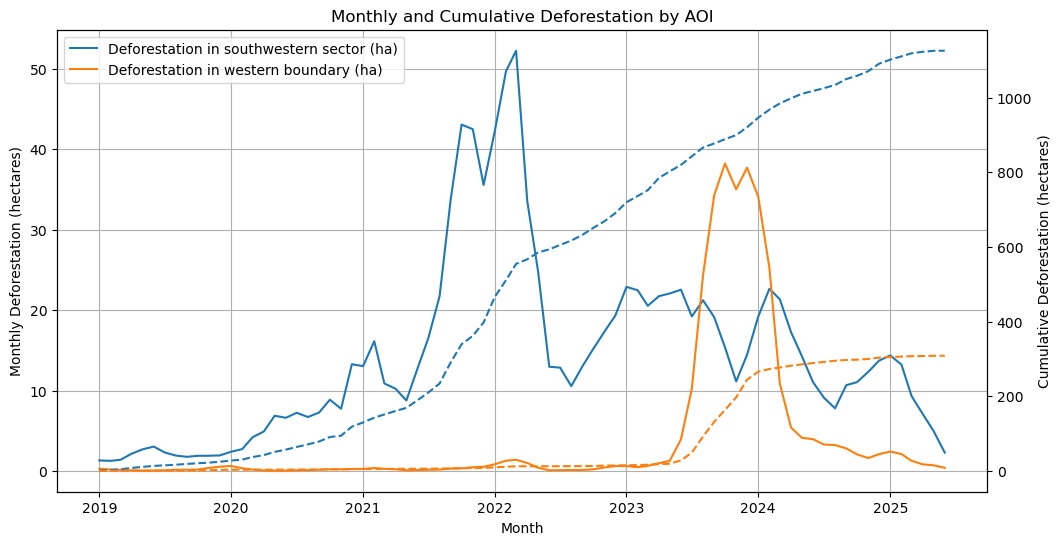

In [ ]:
import matplotlib.pyplot as plt

df_aoi1['Rolling_HA'] = df_aoi1['Deforestation_HA'].rolling(window=3, min_periods=1).mean()
df_aoi2['Rolling_HA'] = df_aoi2['Deforestation_HA'].rolling(window=3, min_periods=1).mean()

# Plot deforestation through time for both AOIs on the same plot with a secondary axis for cumulative stats
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot monthly deforestation
# ax1.plot(df_aoi1['Month'], df_aoi1['Deforestation_HA'], label=f'Monthly Deforestation in {aoi_names[0]} (ha)')
# ax1.plot(df_aoi2['Month'], df_aoi2['Deforestation_HA'], label=f'Monthly Deforestation in {aoi_names[1]} (ha)')
ax1.plot(df_aoi1['Month'], df_aoi1['Rolling_HA'], label=f'Deforestation in {aoi_names[0]} (ha)')
ax1.plot(df_aoi2['Month'], df_aoi2['Rolling_HA'], label=f'Deforestation in {aoi_names[1]} (ha)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Monthly Deforestation (hectares)')
ax1.legend(loc='upper left')
ax1.grid(True)

# Create a secondary y-axis for cumulative deforestation
ax2 = ax1.twinx()
ax2.plot(df_aoi1['Month'], df_aoi1['Cumulative_HA'], label=f'Cumulative Deforestation in {aoi_names[0]} (ha)', linestyle='--')
ax2.plot(df_aoi2['Month'], df_aoi2['Cumulative_HA'], label=f'Cumulative Deforestation in {aoi_names[1]} (ha)', linestyle='--')
ax2.set_ylabel('Cumulative Deforestation (hectares)')
# ax2.legend(loc='upper left'-5)

plt.title('Monthly and Cumulative Deforestation by AOI')
plt.show()

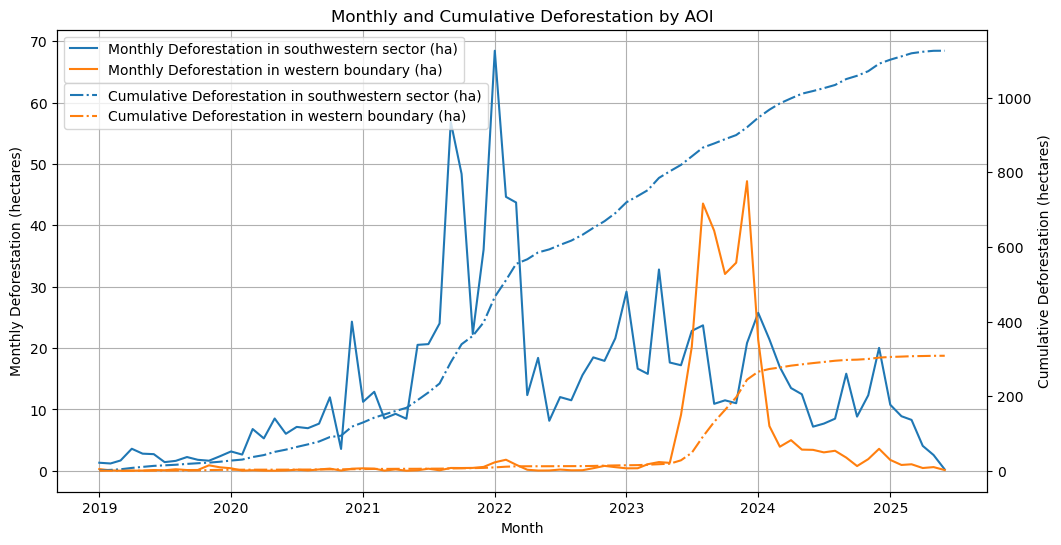

In [27]:
# Plot deforestation through time for both AOIs on the same plot with a secondary axis for cumulative stats
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot monthly deforestation
line1, = ax1.plot(df_aoi1['Month'], df_aoi1['Deforestation_HA'], label=f'Monthly Deforestation in {aoi_names[0]} (ha)')
line2, = ax1.plot(df_aoi2['Month'], df_aoi2['Deforestation_HA'], label=f'Monthly Deforestation in {aoi_names[1]} (ha)')
# line3, = ax1.plot(df_aoi1['Month'], df_aoi1['Rolling_HA'], label=f'Smoothed Deforestation in {aoi_names[0]} (ha)', linestyle='--')
# line4, = ax1.plot(df_aoi2['Month'], df_aoi2['Rolling_HA'], label=f'Smoothed Deforestation in {aoi_names[1]} (ha)', linestyle='--')
ax1.set_xlabel('Month')
ax1.set_ylabel('Monthly Deforestation (hectares)')
ax1.grid(True)

# Create a secondary y-axis for cumulative deforestation
ax2 = ax1.twinx()
line5, = ax2.plot(df_aoi1['Month'], df_aoi1['Cumulative_HA'], label=f'Cumulative Deforestation in {aoi_names[0]} (ha)', linestyle='-.')
line6, = ax2.plot(df_aoi2['Month'], df_aoi2['Cumulative_HA'], label=f'Cumulative Deforestation in {aoi_names[1]} (ha)', linestyle='-.')
ax2.set_ylabel('Cumulative Deforestation (hectares)')

# Create legends
lines_1 = [line1, line2] #, line3, line4]
labels_1 = [line.get_label() for line in lines_1]
legend_1 = ax1.legend(lines_1, labels_1, loc='upper left')

lines_2 = [line5, line6]
labels_2 = [line.get_label() for line in lines_2]
legend_2 = ax1.legend(lines_2, labels_2, loc='upper left', bbox_to_anchor=(0, 0.90))

# Add the first legend back to the plot
ax1.add_artist(legend_1)

plt.title('Monthly and Cumulative Deforestation by AOI')
plt.show()

In [24]:
# Create a list to hold the output data
output = []

In [25]:
# Loop over each pixel in the data array
for y in range(height):
    for x in range(width):
        # Get the alert value from the data array
        alert = data[y,x]
        
        # If the alert value is 0, skip to the next pixel
        if alert == 0:
            continue
        
        # Determine the confidence level and number of days since Dec 31, 2014
        conf = int(str(alert)[0])
        days = int(str(alert)[1:])
        date = np.datetime64('2014-12-31') + np.timedelta64(days, 'D')
        
        # Convert the pixel coordinates to longitude and latitude
        lon, lat = rasterio.transform.xy(transform, y, x)
        
        # Add the data to the output list
        output.append([alert, lon, lat, date, conf])

NameError: name 'height' is not defined

In [ ]:
# Write the output list to a CSV file
with open('GFW_alerts_parsed.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Alert','Longitude', 'Latitude', 'Date', 'Confidence'])
    writer.writerows(output)